In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('Titanic-Dataset.csv')

In [6]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [8]:
df.shape

(891, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [13]:
df["Survived"].value_counts()
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

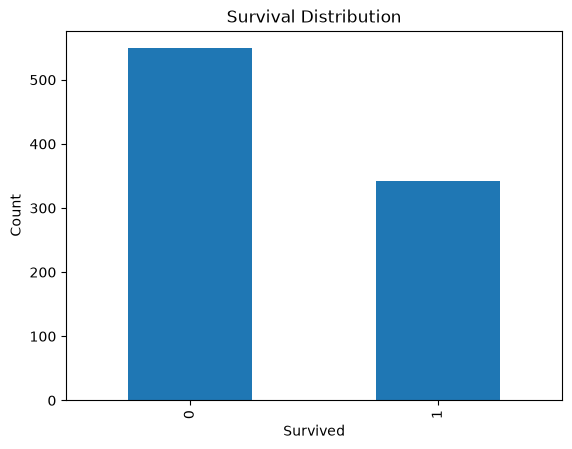

In [14]:
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

The target variable is moderately imbalanced, with more passengers not surviving than surviving. Although the imbalance is not severe, relying solely on accuracy may not provide a complete evaluation of model performance. Therefore, additional metrics such as Precision, Recall, F1-score, and the Confusion Matrix should also be considered.

<Axes: xlabel='Age', ylabel='Count'>

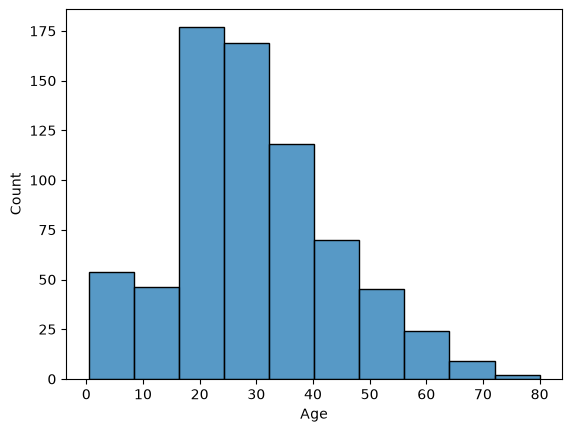

In [15]:
sns.histplot(df["Age"],bins=10)

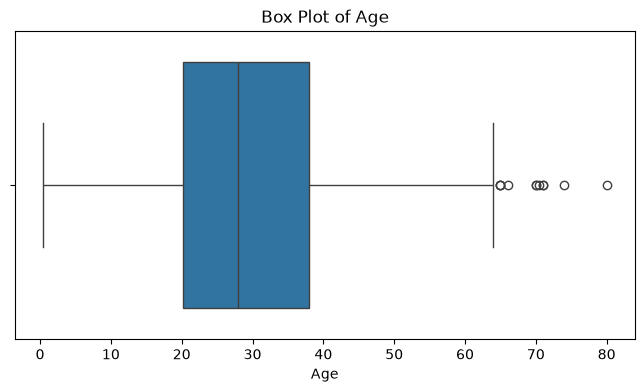

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")
plt.show()


The middle 50% of passengers are approximately between 20 and 38 years old.
The median age is around 28 years, suggesting that most passengers were relatively young adults.
There are a few passengers older than about 65 years, which are identified as outliers by the box plot.
These outliers appear to be plausible ages rather than obvious data errors, so they require further consideration before deciding whether any preprocessing is necessary.

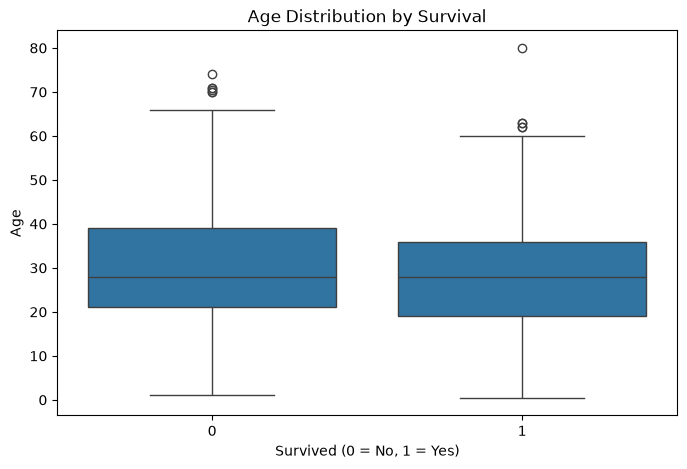

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

The median age of survivors and non-survivors appears to be similar. Both groups have comparable age distributions and contain elderly outliers. Based on this box plot alone, age does not seem to clearly distinguish between passengers who survived and those who did not. However, further analysis with other features is needed before drawing a final conclusion."

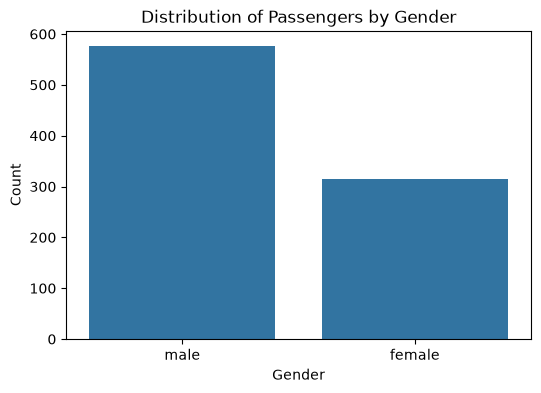

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Distribution of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

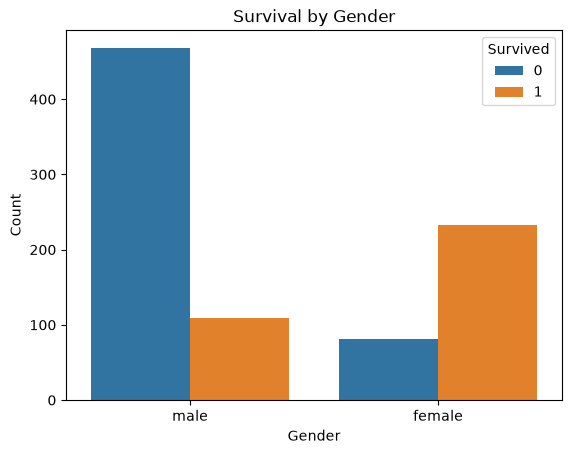

In [19]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Survived")

plt.show()

Gender appears to have a strong relationship with survival. Female passengers had a significantly higher survival rate than male passengers. However, gender alone is not sufficient to perfectly predict survival because some males survived and some females did not. Therefore, Sex is likely to be an important feature for the prediction model

In [20]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

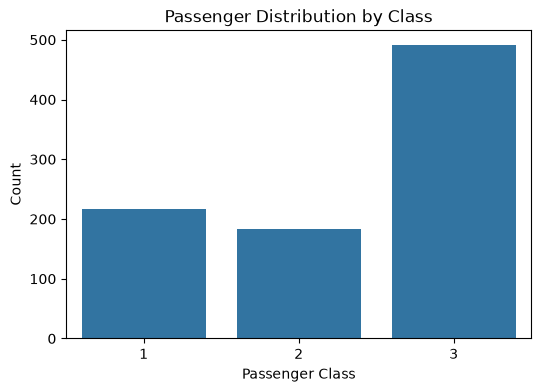

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

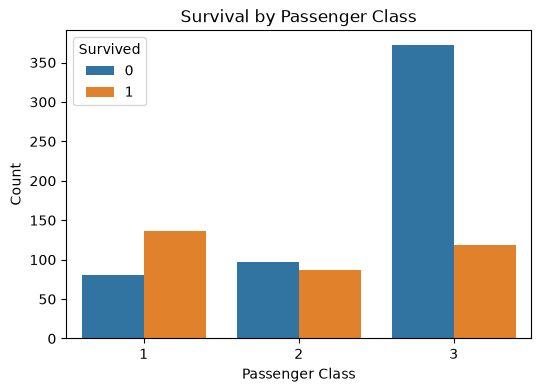

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.legend(title="Survived")

plt.show()

**Observations:**
- Third-class passengers were the largest group in the dataset.
- More first-class passengers survived than died.
- Second-class passengers had a more balanced survival distribution.
- Most third-class passengers did not survive.

**Possible Explanation:**
- Passenger class may have influenced access to lifeboats or evacuation routes, resulting in different survival outcomes.

**Conclusion:**
`Pclass` shows a strong association with passenger survival and is likely to be an important feature for prediction.

In [23]:
pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


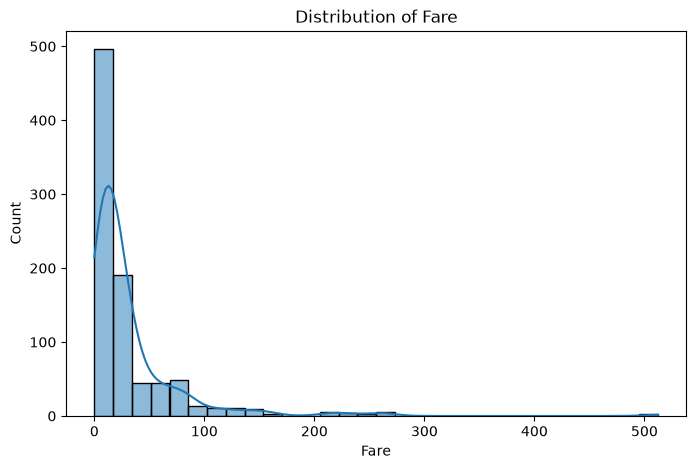

In [24]:
df["Fare"].describe()
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.show()

- Most passengers paid relatively low fares.
- Only a few passengers paid very high fares.
- The Fare distribution is positively (right) skewed.
- The long right tail suggests the presence of high-fare values that may act as outliers.


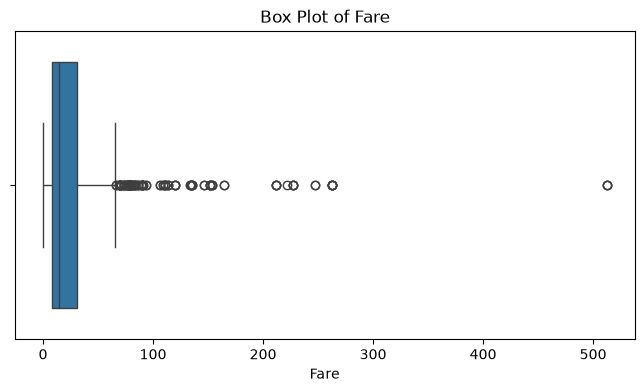

In [25]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Fare")

plt.show()

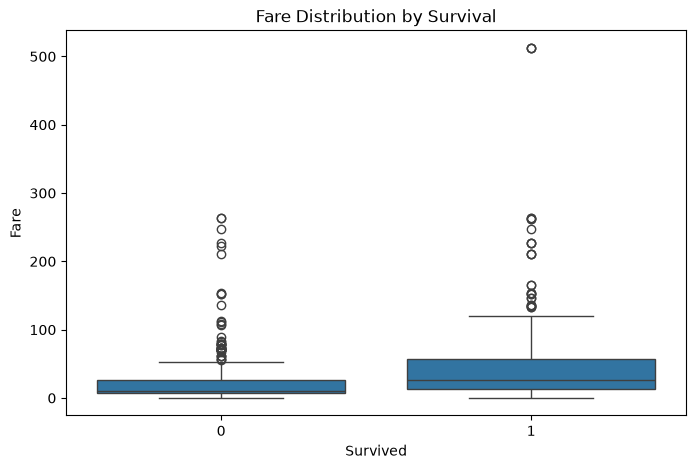

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Fare Distribution by Survival")

plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

- The Fare distribution is highly right-skewed.
- Most passengers paid relatively low fares.
- Fare contains several high-value outliers.
- Survivors generally have higher ticket fares than non-survivors.
- The distributions overlap, indicating Fare alone cannot perfectly predict survival.

In [27]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

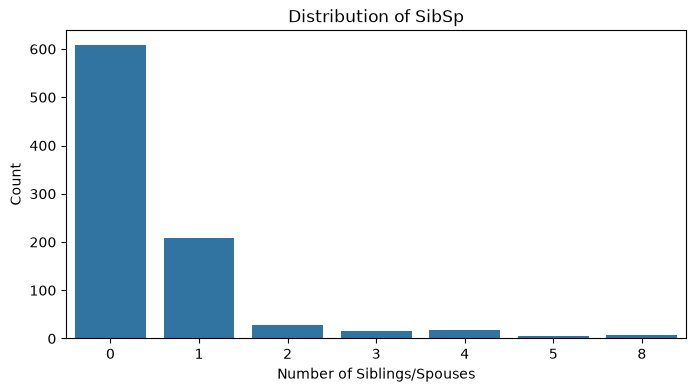

In [28]:
plt.figure(figsize=(8,4))

sns.countplot(x="SibSp", data=df)

plt.title("Distribution of SibSp")
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Count")

plt.show()

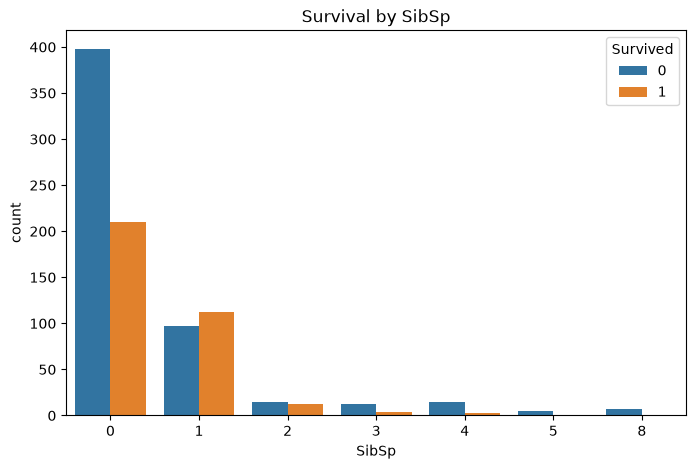

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x="SibSp", hue="Survived", data=df)

plt.title("Survival by SibSp")

plt.show()

In [30]:
pd.crosstab(df["SibSp"], df["Survived"], normalize="index")*100

Survived,0,1
SibSp,,
0,65.460526,34.539474
1,46.411483,53.588517
2,53.571429,46.428571
3,75.000000,25.000000
4,83.333333,16.666667
5,100.000000,0.000000
8,100.000000,0.000000


In [31]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

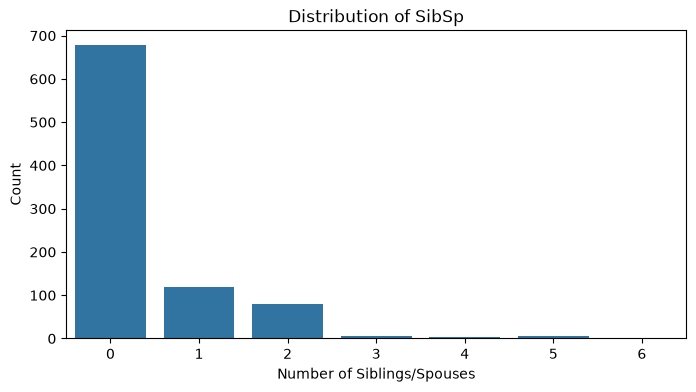

In [32]:
plt.figure(figsize=(8,4))

sns.countplot(x="Parch", data=df)

plt.title("Distribution of SibSp")
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Count")

plt.show()

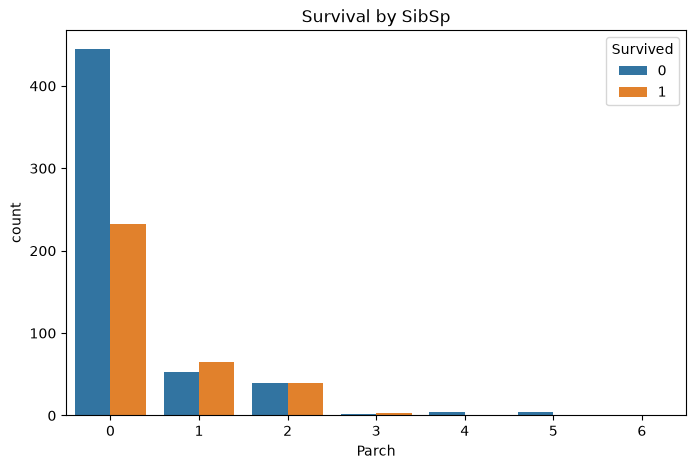

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(x="Parch", hue="Survived", data=df)

plt.title("Survival by SibSp")

plt.show()

In [34]:
pd.crosstab(df["Parch"], df["Survived"], normalize="index")*100

Survived,0,1
Parch,,
0,65.634218,34.365782
1,44.915254,55.084746
2,50.000000,50.000000
3,40.000000,60.000000
4,100.000000,0.000000
5,80.000000,20.000000
6,100.000000,0.000000


- Most passengers traveled without parents or children.
- Passengers traveling with one or two parents/children generally showed higher survival rates than those traveling alone.
- Very large parent/child groups had lower survival rates.
- Extreme values (e.g., Parch = 4 or 6) should be interpreted carefully because they may contain only a few passengers.

In [35]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [36]:
df["Embarked"].value_counts(normalize=True) * 100

Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64

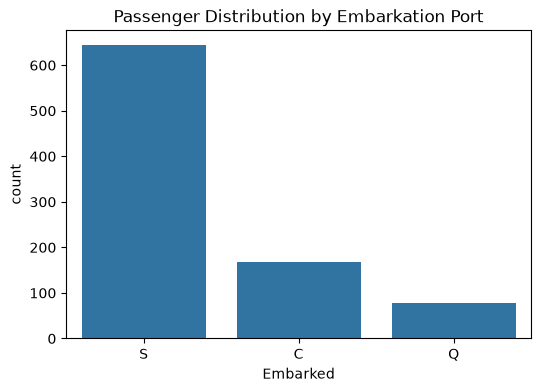

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x="Embarked", data=df)

plt.title("Passenger Distribution by Embarkation Port")

plt.show()

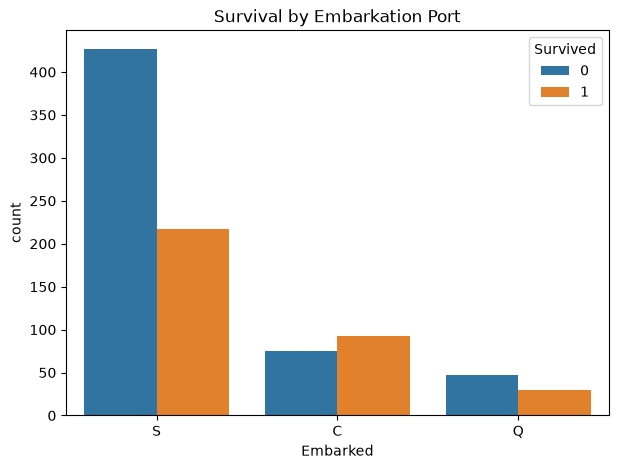

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(x="Embarked", hue="Survived", data=df)

plt.title("Survival by Embarkation Port")

plt.show()

In [39]:
pd.crosstab(df["Embarked"], df["Survived"], normalize="index") * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


In [40]:
df["Cabin"].isnull().sum()

np.int64(687)

In [41]:
df["Cabin"].isnull().mean()*100

np.float64(77.10437710437711)

In [42]:
df["Cabin"].head(20)

0      NaN
1      C85
2      NaN
3     C123
4      NaN
5      NaN
6      E46
7      NaN
8      NaN
9      NaN
10      G6
11    C103
12     NaN
13     NaN
14     NaN
15     NaN
16     NaN
17     NaN
18     NaN
19     NaN
Name: Cabin, dtype: str

In [43]:
df["Cabin"].str[0].value_counts(dropna=False)

Cabin
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [44]:
df["CabinAvailable"] = df["Cabin"].notnull()

In [45]:
cabin_survival=pd.crosstab(
    df["CabinAvailable"],
    df["Survived"],
    normalize="index"
) * 100
print(cabin_survival)

Survived                0          1
CabinAvailable                      
False           70.014556  29.985444
True            33.333333  66.666667


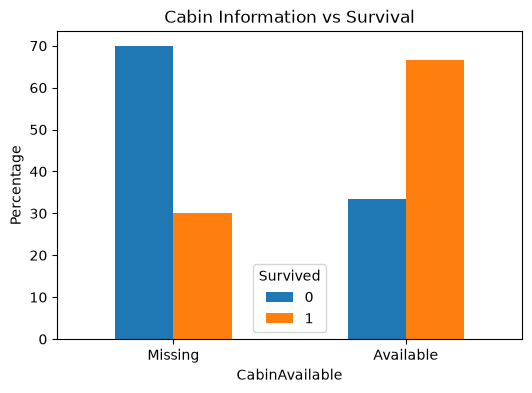

In [46]:
cabin_survival.plot(kind="bar", figsize=(6,4))
plt.ylabel("Percentage")
plt.title("Cabin Information vs Survival")
plt.xticks([0,1], ["Missing", "Available"], rotation=0)
plt.show()

The survival rate is more than double when cabin information is available.
### Investigation: Does Missing Cabin Information Matter?

A new feature called `CabinAvailable` was created:

- True → Cabin information is available.
- False → Cabin information is missing.

### Results

- Passengers with missing cabin information had a survival rate of approximately **30%**.
- Passengers with available cabin information had a survival rate of approximately **67%**.

### Key Insight

The missingness of the `Cabin` feature is not random. It appears to be associated with survival, meaning the absence of data itself carries useful information.

### Conclusion

Instead of dropping the `Cabin` feature solely because it contains many missing values, it should first be investigated. Feature engineering techniques such as extracting the deck or creating a `CabinAvailable` indicator may preserve valuable predictive information.

## Why didn't we drop the Cabin feature immediately?

Initially, the Cabin feature appeared to be a good candidate for removal because approximately 77% of its values were missing.

However, further investigation revealed several important insights:

- Cabin contains meaningful information such as the passenger's deck.
- The deck can be extracted as a new feature through feature engineering.
- Creating a `CabinAvailable` feature showed that passengers with recorded cabin information had a much higher survival rate (~67%) than those without cabin information (~30%).
- This suggests that the missingness of the Cabin feature is informative rather than completely random.

### Key Lesson

A feature should never be dropped solely because it contains many missing values.

Instead, it should first be investigated to determine:
- What information it contains.
- Whether meaningful features can be engineered.
- Whether the missing values themselves carry predictive information.

In [47]:
df["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str

In [48]:
df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False).value_counts()

Name
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [54]:
title = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

In [50]:
pd.crosstab(title, df["Survived"], normalize="index") * 100

Survived,0,1
Name,,
Capt,100.000000,0.000000
Col,50.000000,50.000000
Countess,0.000000,100.000000
Don,100.000000,0.000000
Dr,57.142857,42.857143
Jonkheer,100.000000,0.000000
Lady,0.000000,100.000000
Major,50.000000,50.000000
Master,42.500000,57.500000


The full Name column is not useful for prediction, but extracting the Title preserves meaningful information. This is another example of Feature Engineering, where a raw feature is transformed into a more informative one.

In [53]:
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df["Title"] = df["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
     "Major", "Rev", "Sir", "Jonkheer", "Dona",
     "Mme", "Mlle", "Ms"],
    "Rare"
)

- **EDA** → Use temporary variables when you're exploring ideas.
- **Feature Engineering** → Add new columns to the DataFrame only after you've decided they're genuinely useful.

In [56]:
df["Ticket"].head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: str

In [57]:
df["Ticket"].nunique()

681

In [59]:
df["Ticket"].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [60]:
df[df["Ticket"] == "CA. 2343"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Master
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S,False,Miss
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Mr
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Mr
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S,False,Miss
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Mr
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S,False,Miss


# Feature Engineering & Preprocessing

In [61]:
df_processed = df.copy()

In [62]:
df_processed = df_processed.drop("PassengerId", axis=1)

In [63]:
df_processed.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,Mr


In [64]:
df_processed.drop("Name", axis=1, inplace=True)

In [69]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,True,Mrs
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,False,Mr


In [71]:
df_processed["Deck"] = df_processed["Cabin"].str[0]

In [72]:
df_processed[["Cabin", "Deck"]].head(10)

,Cabin,Deck
0,NaN,NaN
1,C85,C
2,NaN,NaN
3,C123,C
4,NaN,NaN
5,NaN,NaN
6,E46,E
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [90]:
df_processed["Deck"].value_counts(dropna=False)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [89]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,CabinAvailable,Title,Deck,FamilySize,IsAlone
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S,False,Mr,NaN,2,False
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,True,Mrs,C,2,False
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,Miss,NaN,1,True
3,1,1,female,35.0,1,0,113803,53.1000,S,True,Mrs,C,2,False
4,0,3,male,35.0,0,0,373450,8.0500,S,False,Mr,NaN,1,True


In [81]:
df_processed["FamilySize"] = (
    df_processed["SibSp"] +
    df_processed["Parch"] +
    1
)

In [82]:
df_processed[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [83]:
df_processed["IsAlone"] = (
    df_processed["FamilySize"] == 1
)

In [86]:
df_processed[
    ["FamilySize", "IsAlone"]
].head(10)

,FamilySize,IsAlone
0,2,False
1,2,False
2,1,True
3,2,False
4,1,True
5,1,True
6,1,True
7,5,False
8,3,False
9,2,False


In [87]:
print(df_processed.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'CabinAvailable', 'Title', 'Deck', 'FamilySize', 'IsAlone']


In [91]:
df_processed.isnull().sum()

Survived            0
Pclass              0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Embarked            2
CabinAvailable      0
Title               0
Deck              687
FamilySize          0
IsAlone             0
dtype: int64

In [97]:
df_processed["Age"] = df_processed.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)

In [104]:
df_processed["Embarked"] = df_processed["Embarked"].fillna(
    df_processed["Embarked"].mode()[0]
)

In [98]:
df_processed["Deck"] = df_processed["Deck"].fillna(
    "Unknown"
)

In [105]:
df_processed[["Age","Embarked","Deck"]].head()

,Age,Embarked,Deck
0,22.0,S,Unknown
1,38.0,C,C
2,26.0,S,Unknown
3,35.0,S,C
4,35.0,S,Unknown


In [106]:
df_processed.isnull().sum()

Survived          0
Pclass            0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Embarked          0
CabinAvailable    0
Title             0
Deck              0
FamilySize        0
IsAlone           0
dtype: int64

In [107]:
df_processed.drop("Ticket", axis=1, inplace=True)

In [108]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinAvailable,Title,Deck,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,False,Mr,Unknown,2,False
1,1,1,female,38.0,1,0,71.2833,C,True,Mrs,C,2,False
2,1,3,female,26.0,0,0,7.9250,S,False,Miss,Unknown,1,True
3,1,1,female,35.0,1,0,53.1000,S,True,Mrs,C,2,False
4,0,3,male,35.0,0,0,8.0500,S,False,Mr,Unknown,1,True


# Feature Engineering & Preprocessing Summary

## 1. PassengerId
- Dropped because it is a unique identifier.
- It has no predictive relationship with survival.

---

## 2. Name → Title
- Extracted the passenger's title (Mr, Mrs, Miss, Master, etc.).
- Titles provide information about gender, age group, and social status.
- Grouped rare titles into a single category called `Rare`.
- Dropped the original `Name` column.

---

## 3. Cabin → Deck
- Extracted the deck (first letter of the cabin).
- Deck is more informative than the complete cabin number.

---

## 4. Cabin → CabinAvailable
- Created a new feature indicating whether cabin information is available.
- Missing cabin information itself was found to be informative.

---

## 5. FamilySize
- Created using:
  ```
  FamilySize = SibSp + Parch + 1
  ```
- Represents the total number of family members traveling together.

---

## 6. IsAlone
- Created from `FamilySize`.
- `True` if FamilySize = 1, otherwise `False`.
- Helps identify passengers traveling alone.

---

## 7. Age
- Missing values filled using the **median age within each Title**.
- More realistic than using a single overall mean or median.

---

## 8. Embarked
- Filled missing values with the mode (most frequent category).
- Only two values were missing.

---

## 9. Deck
- Missing values filled with `Unknown`.
- Preserves missing information without making incorrect assumptions.

---

## 10. Ticket
- Dropped because it contains too many unique values.
- Raw ticket numbers are not directly useful for machine learning.

---

## Final Engineered Features
- Title
- Deck
- CabinAvailable
- FamilySize
- IsAlone

In [109]:
df_processed.dtypes

Survived            int64
Pclass              int64
Sex                   str
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Embarked              str
CabinAvailable       bool
Title                 str
Deck                  str
FamilySize          int64
IsAlone              bool
dtype: object

# Encoding Techniques

### 1. Label Encoding
- Converts categories into integers.
- Best for binary or ordinal categorical features.

### 2. One-Hot Encoding
- Creates a new column for each category.
- Best for nominal (unordered) categorical features.

### 3. Ordinal Encoding
- Assigns ordered integers to categories.
- Used when categories have a natural ranking.

### 4. Target Encoding
- Replaces each category with the mean target value.
- Suitable for high-cardinality categorical features.
- Requires careful implementation to avoid data leakage.

## Encoding Used in This Project

| Feature | Encoding |
|----------|----------|
| Sex | Binary Mapping (0/1) |
| CabinAvailable | Boolean → Integer |
| IsAlone | Boolean → Integer |
| Embarked | One-Hot Encoding |
| Title | One-Hot Encoding |
| Deck | One-Hot Encoding |
| Pclass | Kept as ordinal values |

In [126]:
df_processed["Sex"] = df["Sex"]

In [127]:
df_processed["Sex"] = df_processed["Sex"].map({
    "male": 0,
    "female": 1
})

In [128]:
df_processed["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [130]:
df_processed["CabinAvailable"] = df_processed["CabinAvailable"].astype(int)

In [131]:
df_processed["IsAlone"] = df_processed["IsAlone"].astype(int)

In [133]:
df_processed = pd.get_dummies(
    df_processed,
    columns=["Embarked", "Title", "Deck"],
    dtype=int
)

KeyError: "None of [Index(['Embarked', 'Title', 'Deck'], dtype='str')] are in the [columns]"

In [134]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,CabinAvailable,FamilySize,IsAlone,...,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,2,0,...,0,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,1,2,0,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,0,0,0,0,0,0,0,0,0,1


In [136]:
X = df_processed.drop("Survived", axis=1)
y = df_processed["Survived"]

In [138]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [139]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 26)
X_test shape: (179, 26)
y_train shape: (712,)
y_test shape: (179,)


In [143]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[["Age", "Fare", "FamilySize"]] = scaler.fit_transform(
    X_train[["Age", "Fare", "FamilySize"]]
)

# Apply the same scaler to test data
X_test[["Age", "Fare", "FamilySize"]] = scaler.transform(
    X_test[["Age", "Fare", "FamilySize"]]
)

In [144]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,CabinAvailable,FamilySize,IsAlone,Embarked_C,...,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
331,1,0,1.253641,0,0,-0.078684,1,-0.554666,1,0,...,0,0,0,1,0,0,0,0,0,0
733,2,0,-0.477284,0,0,-0.377145,0,-0.554666,1,0,...,0,0,0,0,0,0,0,0,0,1
382,3,0,0.215086,0,0,-0.474867,0,-0.554666,1,0,...,0,0,0,0,0,0,0,0,0,1
704,3,0,-0.246494,1,0,-0.476230,0,0.040096,0,0,...,0,0,0,0,0,0,0,0,0,1
813,3,1,-1.785093,4,2,-0.025249,0,3.013909,0,0,...,0,0,0,0,0,0,0,0,0,1


In [150]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

Predicted Values:
[1 0 0 1 1 1 1 0 1 1]


,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [151]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [152]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 0.8156
Accuracy: 81.56%


In [153]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[88 17]
 [16 58]]


In [154]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# Classification Report

## Precision
Measures how many positive predictions were actually correct.

Precision = TP / (TP + FP)

Higher precision means fewer false positives.

---

## Recall
Measures how many actual positive cases were correctly identified.

Recall = TP / (TP + FN)

Higher recall means fewer false negatives.

---

## F1-Score
The harmonic mean of Precision and Recall.

It provides a balanced evaluation when both false positives and false negatives are important.

---

## Support
The number of actual samples belonging to each class.

---

## Model Performance

- Accuracy = 82%
- Precision = 77%
- Recall = 78%
- F1-Score = 78%

The model demonstrates good overall performance and provides a balanced trade-off between precision and recall.

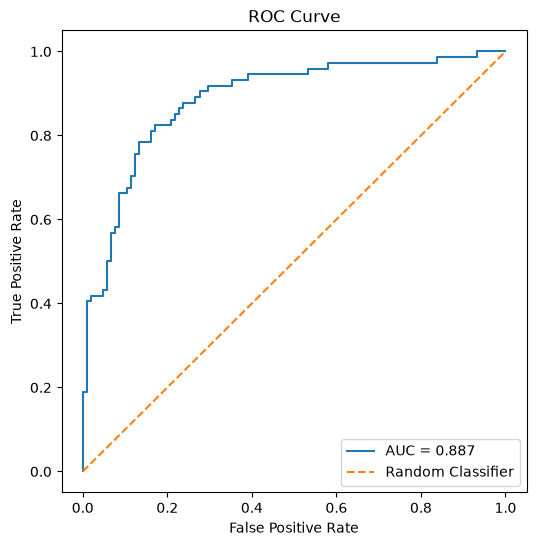

AUC Score: 0.8867438867438867


In [155]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", auc)

# ROC Curve

**ROC (Receiver Operating Characteristic)** is a graphical representation of a binary classification model's performance across different probability thresholds.

It plots:

- **True Positive Rate (TPR)** on the Y-axis
- **False Positive Rate (FPR)** on the X-axis

A curve closer to the top-left corner indicates better model performance.

---

# AUROC

**AUROC (Area Under the Receiver Operating Characteristic Curve)** summarizes the ROC curve into a single value.

Interpretation:

- **1.0** → Perfect classifier
- **0.9–1.0** → Excellent
- **0.8–0.9** → Very Good
- **0.7–0.8** → Good
- **0.5** → Random guessing

Our Logistic Regression model achieved an **AUROC of 0.887**, indicating a very good ability to distinguish between survivors and non-survivors.

In [156]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,Sex,1.503490
12,Title_Master,1.411564
21,Deck_E,1.007911
15,Title_Mrs,0.877601
20,Deck_D,0.563336
6,CabinAvailable,0.259240
22,Deck_F,0.235865
9,Embarked_C,0.233641
5,Fare,0.216232
18,Deck_B,0.189979


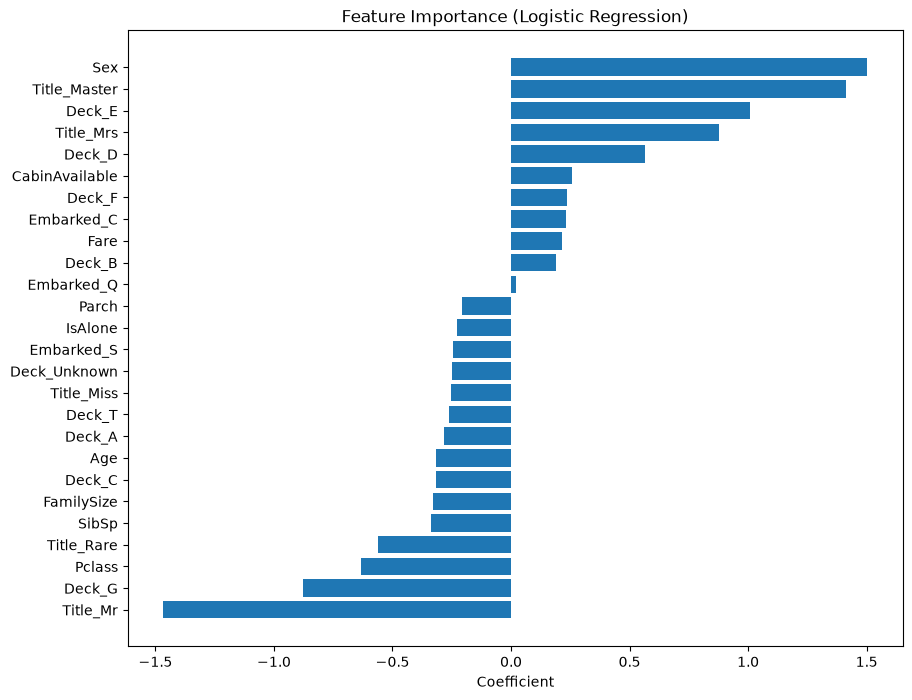

In [157]:
import matplotlib.pyplot as plt

coefficients = coefficients.sort_values("Coefficient")

plt.figure(figsize=(10,8))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()

## Interpreting Logistic Regression Coefficients

The coefficient of a feature indicates how that feature influences the model's prediction while keeping all other features constant.

- Positive coefficient → Increases the predicted probability of the positive class (Survived = 1).
- Negative coefficient → Decreases the predicted probability of the positive class (Survived = 1), increasing the probability of the negative class (Survived = 0).

A coefficient does **not** represent the number of people who survived or died. Instead, it represents the direction and strength of the feature's influence on the model's prediction.

In [161]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(
    LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.82122905 0.81460674 0.81460674 0.83146067 0.86516854]
Average Accuracy: 0.8294143493817085
Standard Deviation: 0.018910733264867863
